# Fitting Data from an Experiment

The generic physics experiment goes as follows:  we measure some quantity, $y$, as a function of some other quantity, $x$.  We plot that data, and then we attempt to find a function, $y_{fit} = f(x)$ that best describes the data.

In addition, in most (maybe all?) experiments, we have uncertainties,$\delta y$, associated with each data point.  We should understand more about how this affects the fitting procedure.

One of the oldest and most widely used methods for determining model parameters is **ordinary least squares**. Without measurement uncertainties, it minimizes the unweighted residual sum of squares:

$S = \sum_i^N [y_i-y_{fit}(x_i)]^2$

Note that $y_{fit}(x)$ necessarily depends on some number of parameters, $(a,b,c,...)$. For example, for a quadratic fitting function, we might have that:

$y_{fit}(x) = a x^2 + b x + c$

To find the minimum of $S$, we solve the set of equations defined by:

$\frac{\partial S}{\partial a} = 0, \frac{\partial S}{\partial b} = 0, \frac{\partial S}{\partial c} = 0, ...$

For a polynomial model, least squares is linear in the coefficients. If the data provide a full-rank design matrix, the fitted coefficients have a unique global minimum. Nonlinear models may instead have curved parameter dependencies or multiple local minima, so sensible initial parameter values can become important.

When independent Gaussian one-standard-deviation uncertainties $\sigma_i$ are known for the $N$ data points, weighted least squares minimizes the statistical chi-square:

$\chi^2 = \sum_i^N \left [\frac{y_i-y_{fit}(x_i)}{\sigma_i}\right]^2$

The fitted covariance matrix estimates parameter uncertainties and correlations. The shaded regions below are central 68% fit-uncertainty bands for the estimated mean line; they are not prediction intervals for new individual measurements.

### Let us now investigate how uncertainties affect both (a) the fit parameters and (b) the confidence interval on the fit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import sys; sys.path.insert(0, '..')
from P201_Functions import *

rng = np.random.default_rng(441)

def report_fit_diagnostics(x, y, parameters, sigma=None):
    residuals = np.asarray(y)-fitfunction(np.asarray(x), *parameters)
    dof = len(residuals)-len(parameters)
    if sigma is None:
        rss = np.sum(residuals**2)
        print(f"Residual sum of squares = {rss:.5f}")
        print(f"Residual standard error = {np.sqrt(rss/dof):.5f}")
    else:
        chi2 = np.sum((residuals/np.asarray(sigma))**2)
        print(f"Chi^2 / dof = {chi2:.3f} / {dof}")
        print(f"Reduced chi^2 = {chi2/dof:.3f}")

# Matplotlib includes a dark theme; no additional styling package is required.
dark_mode = False
if dark_mode:
    plt.style.use('dark_background')
    linecolor = 'w'
else:
    linecolor = 'k'

In [2]:
# create some fake data

npts = 11
xlow = 0.5
xhigh = 5.5

xi = np.linspace(xlow,xhigh,npts)
yrandom = rng.normal(loc=0.0, scale=0.2, size=npts)

# The "equation" that we will fit in all of these examples is the line y=x.  Thus, we expect,
# in all cases, a slope of 1 and a y-intercept of 0.
yi = xi + yrandom

Text(0.5, 1.0, 'No Uncertainties')

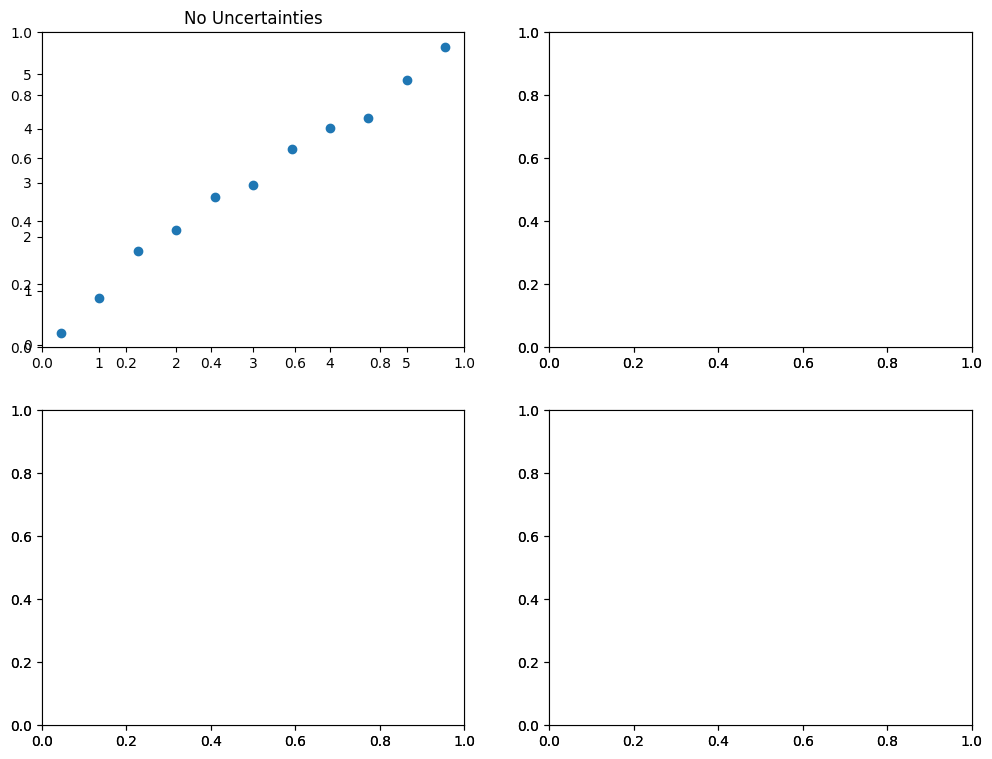

In [3]:
plt.rcParams["figure.figsize"] = (12,9)


figure, axis = plt.subplots(2, 2)
plot1 = plt.subplot2grid((2, 2), (0, 0), rowspan=1, colspan=1)
plot2 = plt.subplot2grid((2, 2), (0, 1), rowspan=1, colspan=1)
plot3 = plt.subplot2grid((2, 2), (1, 0), rowspan=1, colspan=1)
plot4 = plt.subplot2grid((2, 2), (1, 1), rowspan=1, colspan=1)

plot1.plot(xi,yi,'o')
plot1.set_title("No Uncertainties")


## Case 1:  Linear Fit with No Uncertainties

Residual sum of squares = 0.34227
Residual standard error = 0.19501
Coefficients (from curve_fit)
[0.00403962 0.99409018]
Covariance Matrix (from curve_fit)
[[ 0.01590352 -0.00414876]
 [-0.00414876  0.00138292]]

Final Result: y = (0.99 +/- 0.04) x + (0.00 +/- 0.13)


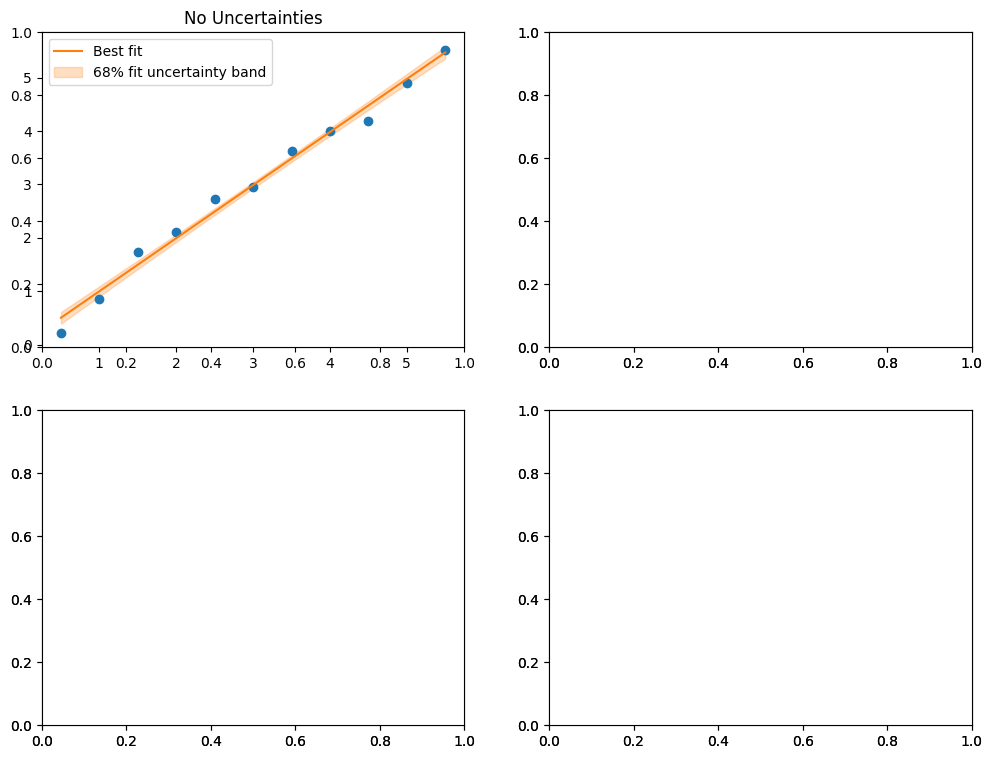

In [4]:
from scipy.optimize import curve_fit

# define a linear fit function
def fitfunction(x,*paramlist):
    return paramlist[0]+paramlist[1]*x

# initialize the parameters of the fitting function (to zero)
init_vals = [0.0 for x in range(2)]

# call the curve fitting routine, passing to it the name of the fitting function,
# the data to be fit (x,y), and the array of initial values of the parameters. Curve_fit
# returns an array of the optimized parameters (popt), and the covariance matrix
# of the fit.  The errors on the fit parameters are given by the square root of the diagonal
# elements of the covariance matrix!

popt, pcov = curve_fit(fitfunction,xi,yi,p0=init_vals)
perr = np.sqrt(np.diag(pcov))

# We want to visualize not only the line of best fit, but also the lines that correspond
# to the central 68% (approximately one-sigma) fit-uncertainty band.
#
# I am not going to go into great detail on how this works here :)  If you want to learn
# more about this, I suggest you take Physics 421 or 441 at some point!
#
ps = rng.multivariate_normal(popt,pcov,10000)
ysample=np.asarray([fitfunction(xi,*pi) for pi in ps])
lower = np.percentile(ysample,16.0,axis=0)
upper = np.percentile(ysample,84.0,axis=0)
report_fit_diagnostics(xi, yi, popt)

# Finally print out the coefficients, covariance matrix, and final results!

print("Coefficients (from curve_fit)")
print (popt)
print("Covariance Matrix (from curve_fit)")
print (pcov)

print()
print ("Final Result: y = (%0.2f +/- %0.2f) x + (%0.2f +/- %0.2f)" % (popt[1],perr[1],popt[0],perr[0]))

# Since we are going to be comparing the results of fitting different data sets, create
# and stat to fill some arrays to hold the fit results - (slope +/- dslope), (yint +/ dyint)

slope = []
dslope = []
yint = []
dyint = []
type = []

slope.append(popt[1])
dslope.append(perr[1])
yint.append(popt[0])
dyint.append(perr[0])
type.append('None')

plt.rcParams["figure.figsize"] = (12,9)

fit_line, = plot1.plot(xi, fitfunction(xi, *popt), label='Best fit')
plot1.fill_between(xi, lower, upper, color=fit_line.get_color(), alpha=0.25,
                   label='68% fit uncertainty band')
plot1.legend()

figure

## Case 2:  Linear Fit with Uniform Uncertainties

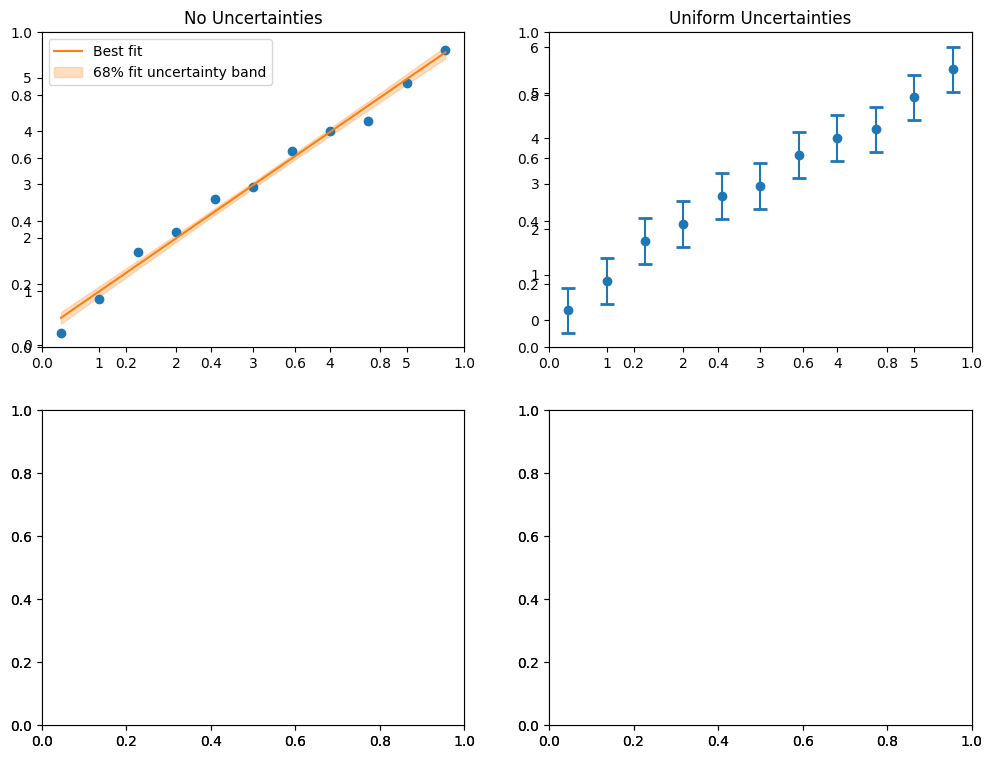

In [5]:
sigmai = np.array([0.5 for i in range(npts)])
plot2.errorbar(xi, yi, yerr=sigmai, fmt='o', capsize=5, capthick=2)
plot2.set_title("Uniform Uncertainties")

figure

Chi^2 / dof = 1.369 / 9
Reduced chi^2 = 0.152
Coefficients (from curve_fit)
[0.00403962 0.99409018]
Covariance Matrix (from curve_fit)
[[ 0.10454612 -0.02727298]
 [-0.02727298  0.009091  ]]

Final Result: y = (0.99 +/- 0.10) x + (0.00 +/- 0.32)


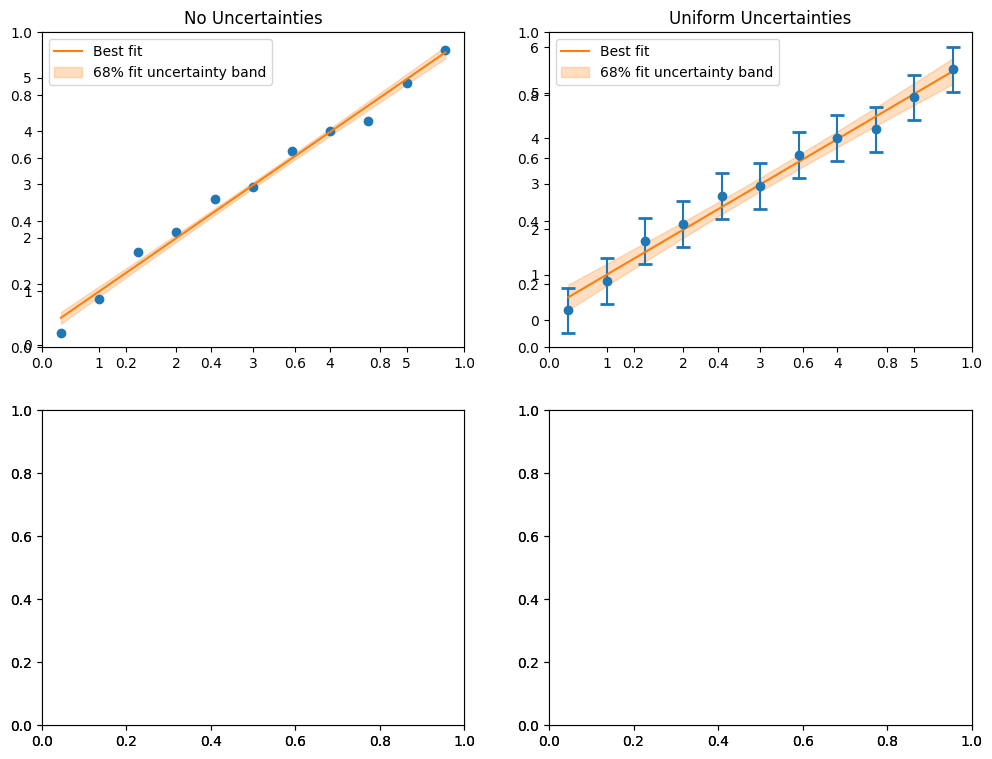

In [6]:
init_vals = [0.0 for x in range(2)]
popt, pcov = curve_fit(fitfunction,xi,yi,p0=init_vals,sigma=sigmai,
                       absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

ps = rng.multivariate_normal(popt,pcov,10000)
ysample=np.asarray([fitfunction(xi,*pi) for pi in ps])

lower = np.percentile(ysample,16.0,axis=0)
upper = np.percentile(ysample,84.0,axis=0)
report_fit_diagnostics(xi, yi, popt, sigmai)

print("Coefficients (from curve_fit)")
print (popt)
print("Covariance Matrix (from curve_fit)")
print (pcov)

print()
print ("Final Result: y = (%0.2f +/- %0.2f) x + (%0.2f +/- %0.2f)" % (popt[1],perr[1],popt[0],perr[0]))

fit_line, = plot2.plot(xi, fitfunction(xi, *popt), label='Best fit')
plot2.fill_between(xi, lower, upper, color=fit_line.get_color(), alpha=0.25,
                   label='68% fit uncertainty band')
plot2.legend()



slope.append(popt[1])
dslope.append(perr[1])
yint.append(popt[0])
dyint.append(perr[0])
type.append('Uniform')

figure

## Case 3:  Linear Fit with Increasing Uncertainties

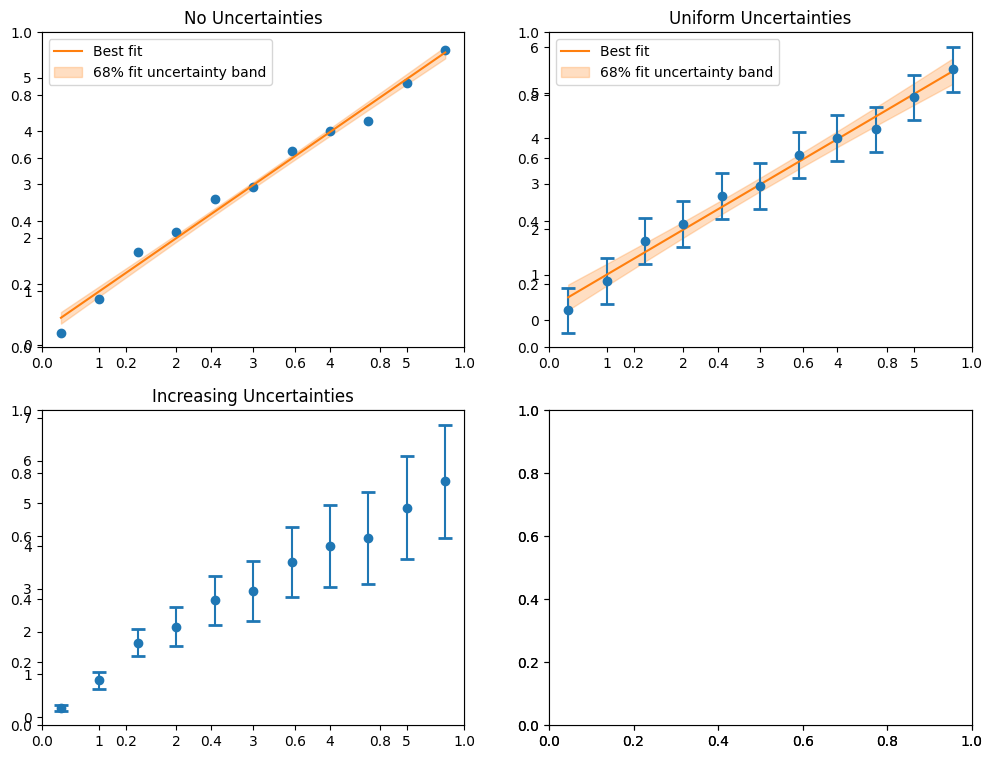

In [7]:
xl = xlow + 0.1
sigmai = np.array([0.1 + 0.25*(xi[i]-xl) for i in range(npts)])
plot3.errorbar(xi, yi, yerr=sigmai, fmt='o', capsize=5, capthick=2)
plot3.set_title("Increasing Uncertainties")

figure

Chi^2 / dof = 2.346 / 9
Reduced chi^2 = 0.261
Coefficients (from curve_fit)
[-0.32804959  1.1394132 ]
Covariance Matrix (from curve_fit)
[[ 0.00982361 -0.00715988]
 [-0.00715988  0.00946272]]

Final Result: y = (1.14 +/- 0.10) x + (-0.33 +/- 0.10)


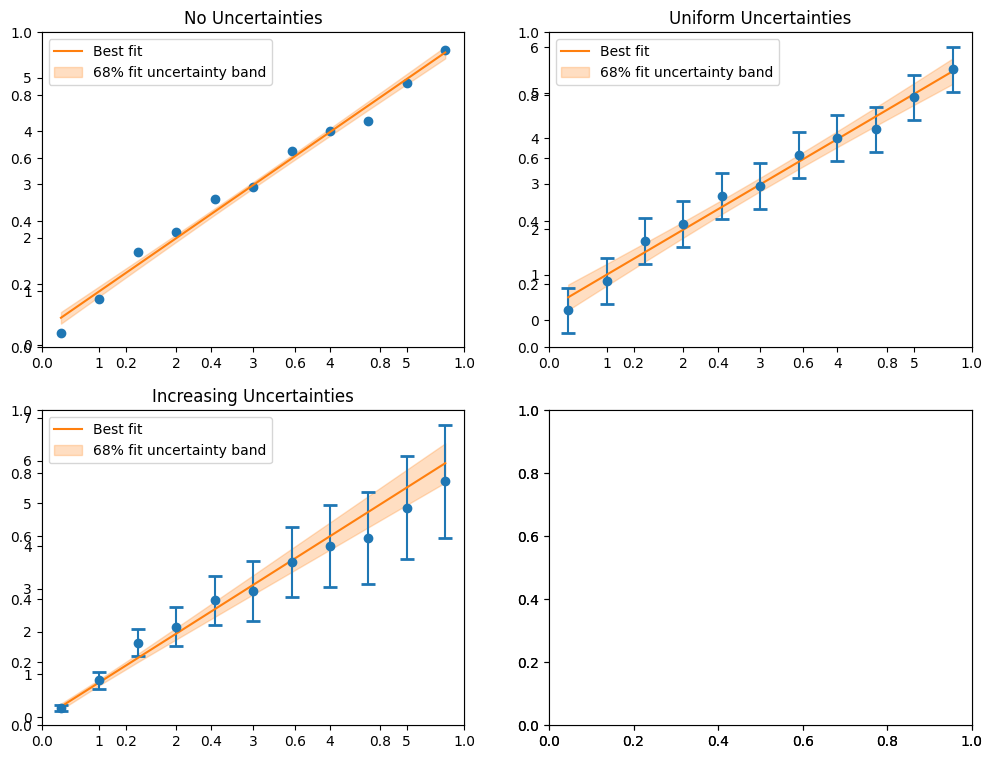

In [8]:
init_vals = [0.0 for x in range(2)]
popt, pcov = curve_fit(fitfunction,xi,yi,p0=init_vals,sigma=sigmai,
                       absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

ps = rng.multivariate_normal(popt,pcov,10000)
ysample=np.asarray([fitfunction(xi,*pi) for pi in ps])

lower = np.percentile(ysample,16.0,axis=0)
upper = np.percentile(ysample,84.0,axis=0)
report_fit_diagnostics(xi, yi, popt, sigmai)

print("Coefficients (from curve_fit)")
print (popt)
print("Covariance Matrix (from curve_fit)")
print (pcov)

print()
print ("Final Result: y = (%0.2f +/- %0.2f) x + (%0.2f +/- %0.2f)" % (popt[1],perr[1],popt[0],perr[0]))

fit_line, = plot3.plot(xi, fitfunction(xi, *popt), label='Best fit')
plot3.fill_between(xi, lower, upper, color=fit_line.get_color(), alpha=0.25,
                   label='68% fit uncertainty band')
plot3.legend()

slope.append(popt[1])
dslope.append(perr[1])
yint.append(popt[0])
dyint.append(perr[0])
type.append('Increasing')

figure

## Case 4:  Linear Fit with Increasing Uncertainties at Endpoints

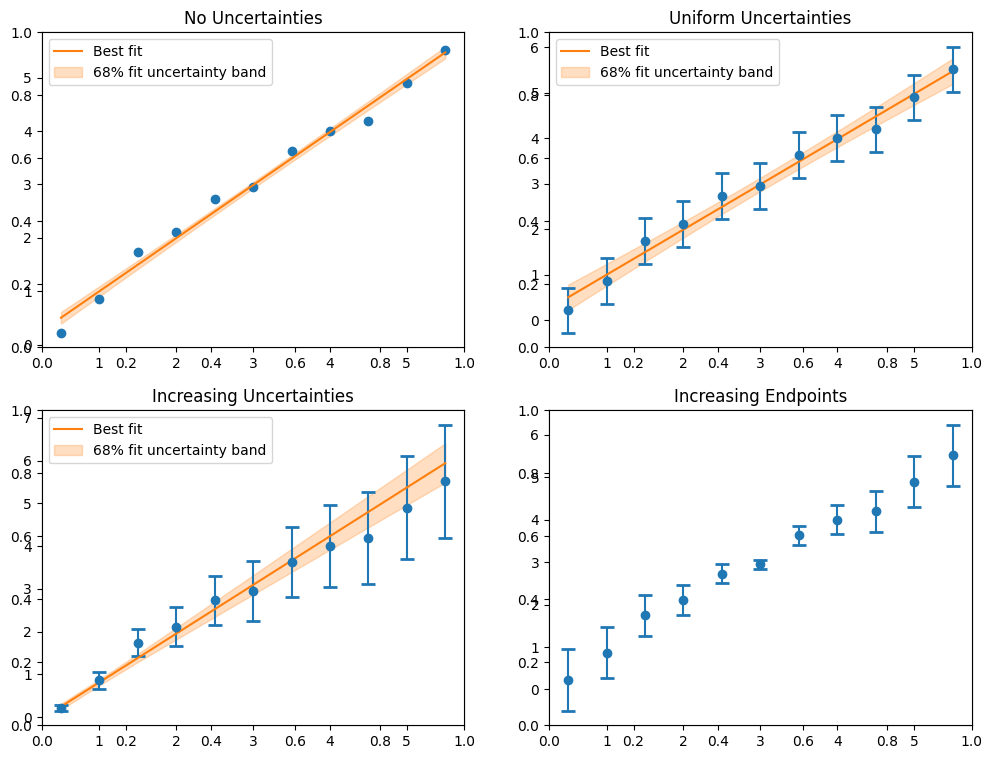

In [9]:
xmid = (xlow+xhigh)/2.0
sigmai = 0.1+0.25*np.abs(xi-xmid)
plot4.errorbar(xi, yi, yerr=sigmai, fmt='o', capsize=5, capthick=2)
plot4.set_title("Increasing Endpoints")

figure

Chi^2 / dof = 2.464 / 9
Reduced chi^2 = 0.274
Coefficients (from curve_fit)
[0.13467498 0.9573969 ]
Covariance Matrix (from curve_fit)
[[ 0.10341094 -0.03255523]
 [-0.03255523  0.01085174]]

Final Result: y = (0.96 +/- 0.10) x + (0.13 +/- 0.32)


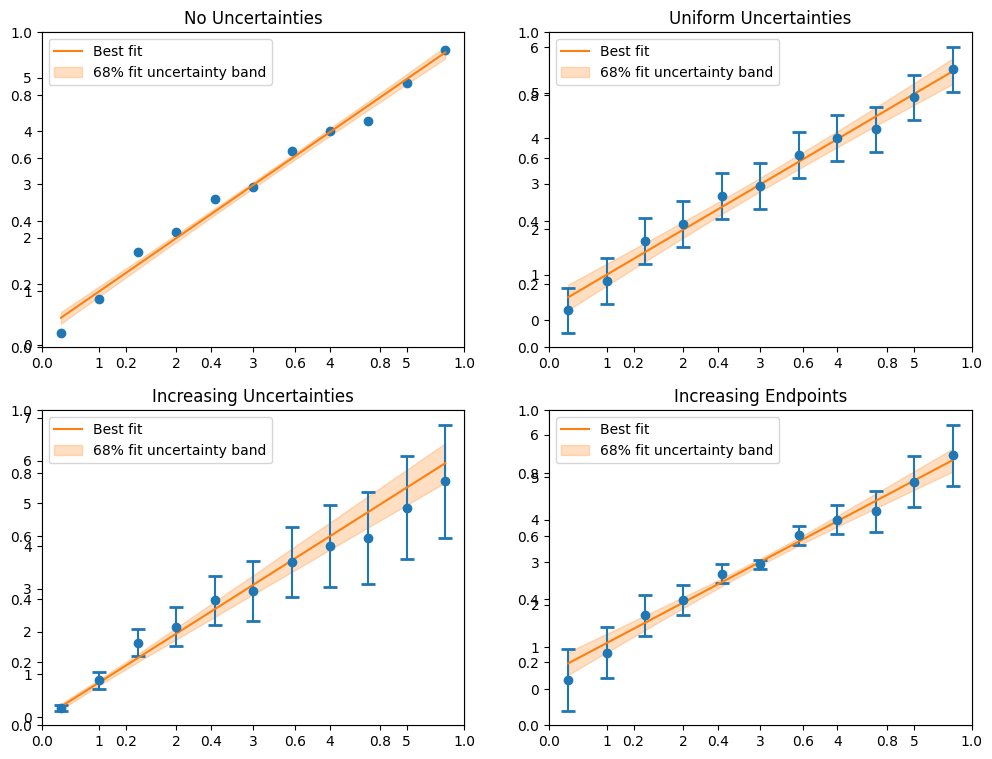

In [10]:
init_vals = [0.0 for x in range(2)]
popt, pcov = curve_fit(fitfunction,xi,yi,p0=init_vals,sigma=sigmai,
                       absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

ps = rng.multivariate_normal(popt,pcov,10000)
ysample=np.asarray([fitfunction(xi,*pi) for pi in ps])

lower = np.percentile(ysample,16.0,axis=0)
upper = np.percentile(ysample,84.0,axis=0)
report_fit_diagnostics(xi, yi, popt, sigmai)

print("Coefficients (from curve_fit)")
print (popt)
print("Covariance Matrix (from curve_fit)")
print (pcov)

print()
print ("Final Result: y = (%0.2f +/- %0.2f) x + (%0.2f +/- %0.2f)" % (popt[1],perr[1],popt[0],perr[0]))

fit_line, = plot4.plot(xi, fitfunction(xi, *popt), label='Best fit')
plot4.fill_between(xi, lower, upper, color=fit_line.get_color(), alpha=0.25,
                   label='68% fit uncertainty band')
plot4.legend()

slope.append(popt[1])
dslope.append(perr[1])
yint.append(popt[0])
dyint.append(perr[0])
type.append('Endpoints')

figure

## Preliminary Conclusions

1. Multiplying every uncertainty by the same constant does not change the best-fit slope or intercept: every term in $\chi^2$ receives the same relative weight. It **does** change the parameter uncertainties and the width of the fit-uncertainty band when the supplied $\sigma_i$ values are interpreted as absolute uncertainties (`absolute_sigma=True`).

2. If the uncertainties are non-uniform, they change the relative influence of the data points. The fitted parameters and their uncertainty band therefore depend on both the locations of the measurements and the pattern of $\sigma_i$.



In [11]:
df = pd.DataFrame({'Fit Type':type, 'Slope':slope, 'Error in Slope':dslope, 'Y Intercept':yint, 'Error in Y Intercept':dyint})
df.head()

,Fit Type,Slope,Error in Slope,Y Intercept,Error in Y Intercept
0,None,0.994090,0.037188,0.004040,0.126109
1,Uniform,0.994090,0.095347,0.004040,0.323336
2,Increasing,1.139413,0.097276,-0.328050,0.099114
3,Endpoints,0.957397,0.104172,0.134675,0.321576


## Case 5:  Determining the Y-intercept with increasing uncertainties at small x

In many experiments, the uncertainties increase as the independent variable ($x$) becomes small.  We seek to understand how best to design our experiment in these situations to optimize the determination of the y-intercept (at $x=0$).

(-3.0, 15.0)

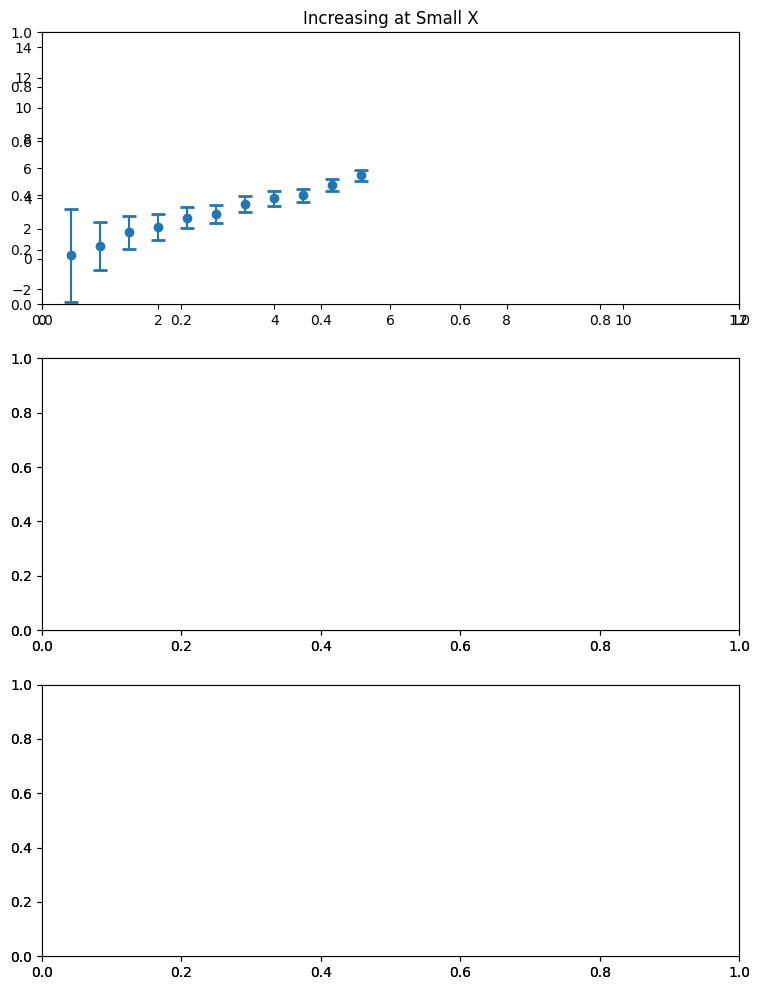

In [12]:
plt.rcParams["figure.figsize"] = (9,12)

figure2, axis = plt.subplots(3, 1)

plot1 = plt.subplot2grid((3, 1), (0, 0), rowspan=1, colspan=1)
plot2 = plt.subplot2grid((3, 1), (1, 0), rowspan=1, colspan=1)
plot3 = plt.subplot2grid((3, 1), (2, 0), rowspan=1, colspan=1)


sigmai = np.array([0.1+ 1.5/np.abs(xi[i]) for i in range(npts)])
plot1.errorbar(xi, yi, yerr=sigmai, fmt='o', capsize=5, capthick=2)
plot1.set_title("Increasing at Small X")
plot1.set_xlim([0,12])
plot1.set_ylim([-3,15])


Chi^2 / dof = 0.654 / 9
Reduced chi^2 = 0.073
Coefficients (from curve_fit)
[0.18494244 0.94802165]
Covariance Matrix (from curve_fit)
[[ 0.40180226 -0.08944177]
 [-0.08944177  0.02146711]]

Final Result: y = (0.95 +/- 0.15) x + (0.18 +/- 0.63)


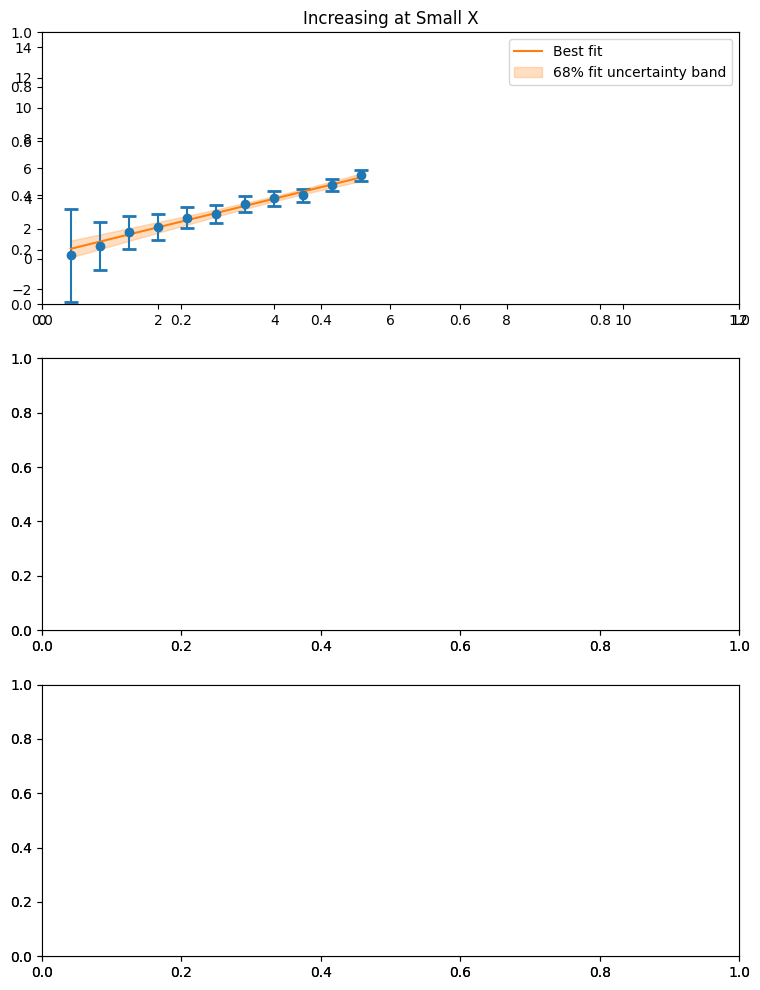

In [13]:
init_vals = [0.0 for x in range(2)]
popt, pcov = curve_fit(fitfunction,xi,yi,p0=init_vals,sigma=sigmai,
                       absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

ps = rng.multivariate_normal(popt,pcov,10000)
ysample=np.asarray([fitfunction(xi,*pi) for pi in ps])

lower = np.percentile(ysample,16.0,axis=0)
upper = np.percentile(ysample,84.0,axis=0)
report_fit_diagnostics(xi, yi, popt, sigmai)

print("Coefficients (from curve_fit)")
print (popt)
print("Covariance Matrix (from curve_fit)")
print (pcov)

print()
print ("Final Result: y = (%0.2f +/- %0.2f) x + (%0.2f +/- %0.2f)" % (popt[1],perr[1],popt[0],perr[0]))

fit_line, = plot1.plot(xi, fitfunction(xi, *popt), label='Best fit')
plot1.fill_between(xi, lower, upper, color=fit_line.get_color(), alpha=0.25,
                   label='68% fit uncertainty band')
plot1.legend()

slope.append(popt[1])
dslope.append(perr[1])
yint.append(popt[0])
dyint.append(perr[0])
type.append('Increasing at Small X')

figure2

## Preliminary Conclusion:  our knowledge of the y-intercept is very limited!

In [14]:
df = pd.DataFrame({'Fit Type':type, 'Slope':slope, 'Error in Slope':dslope, 'Y Intercept':yint, 'Error in Y Intercept':dyint})
df.head()

,Fit Type,Slope,Error in Slope,Y Intercept,Error in Y Intercept
0,None,0.994090,0.037188,0.004040,0.126109
1,Uniform,0.994090,0.095347,0.004040,0.323336
2,Increasing,1.139413,0.097276,-0.328050,0.099114
3,Endpoints,0.957397,0.104172,0.134675,0.321576
4,Increasing at Small X,0.948022,0.146517,0.184942,0.633879


## Case 6:   Decrease the range of x - Focus on the small x region

What is the impact of taking the same amount of data as in the original experiment, but focusing on the small x region?

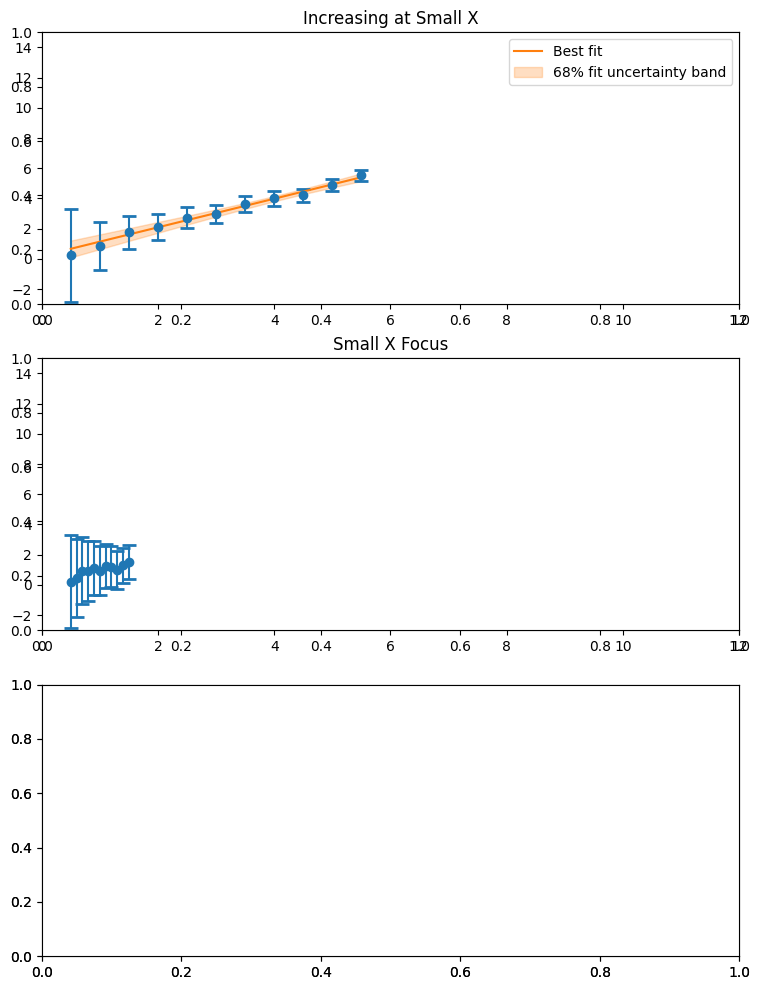

In [15]:
# create some fake data

npts = 11
xlow = 0.5
xhigh = 1.5

xl = xlow + 0.01
xmid = (xhigh+xlow)/2.0+0.01

xi = np.linspace(xlow,xhigh,npts)
yi = xi + yrandom

sigmai = np.array([0.1+ 1.5/np.abs(xi[i]) for i in range(npts)])
plot2.errorbar(xi, yi, yerr=sigmai, fmt='o', capsize=5, capthick=2)
plot2.set_title("Small X Focus")
plot2.set_xlim([0,12])
plot2.set_ylim([-3,15])

figure2

Chi^2 / dof = 0.105 / 9
Reduced chi^2 = 0.012
Coefficients (from curve_fit)
[0.17592298 0.8289039 ]
Covariance Matrix (from curve_fit)
[[ 4.13870553 -3.34539908]
 [-3.34539908  2.85321476]]

Final Result: y = (0.83 +/- 1.69) x + (0.18 +/- 2.03)


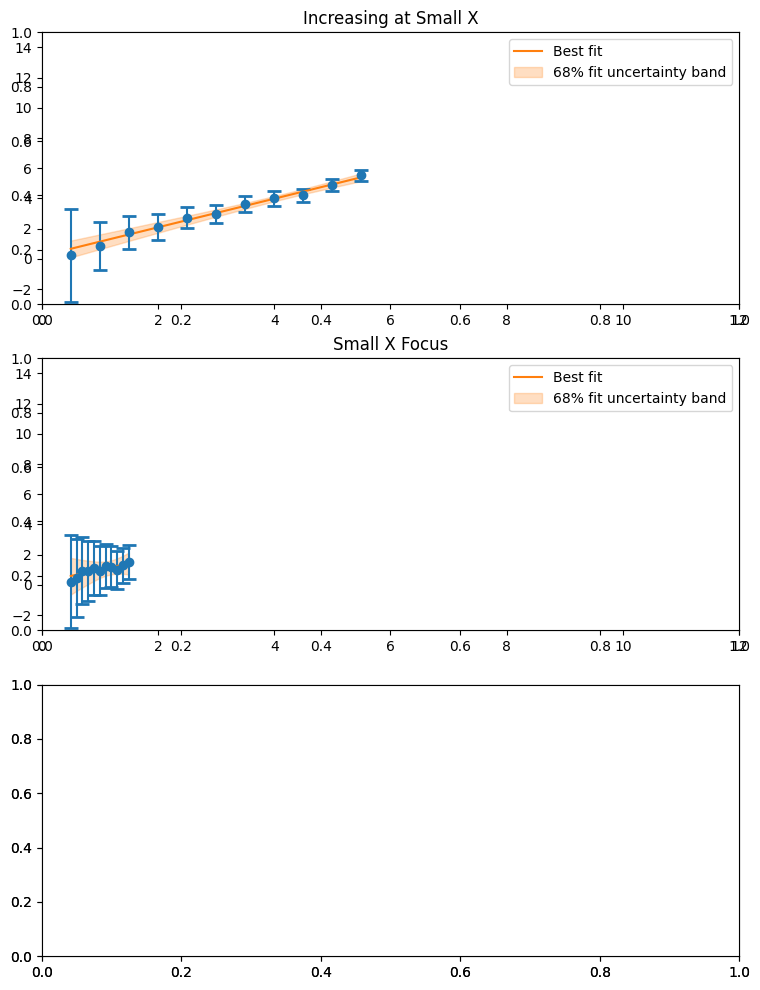

In [16]:
init_vals = [0.0 for x in range(2)]
popt, pcov = curve_fit(fitfunction,xi,yi,p0=init_vals,sigma=sigmai,
                       absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

ps = rng.multivariate_normal(popt,pcov,10000)
ysample=np.asarray([fitfunction(xi,*pi) for pi in ps])

lower = np.percentile(ysample,16.0,axis=0)
upper = np.percentile(ysample,84.0,axis=0)
report_fit_diagnostics(xi, yi, popt, sigmai)

print("Coefficients (from curve_fit)")
print (popt)
print("Covariance Matrix (from curve_fit)")
print (pcov)

print()
print ("Final Result: y = (%0.2f +/- %0.2f) x + (%0.2f +/- %0.2f)" % (popt[1],perr[1],popt[0],perr[0]))

fit_line, = plot2.plot(xi, fitfunction(xi, *popt), label='Best fit')
plot2.fill_between(xi, lower, upper, color=fit_line.get_color(), alpha=0.25,
                   label='68% fit uncertainty band')
plot2.legend()

slope.append(popt[1])
dslope.append(perr[1])
yint.append(popt[0])
dyint.append(perr[0])
type.append('Small X Range')

figure2

In [17]:
df = pd.DataFrame({'Fit Type':type, 'Slope':slope, 'Error in Slope':dslope, 'Y Intercept':yint, 'Error in Y Intercept':dyint})
df.head(10)

,Fit Type,Slope,Error in Slope,Y Intercept,Error in Y Intercept
0,None,0.994090,0.037188,0.004040,0.126109
1,Uniform,0.994090,0.095347,0.004040,0.323336
2,Increasing,1.139413,0.097276,-0.328050,0.099114
3,Endpoints,0.957397,0.104172,0.134675,0.321576
4,Increasing at Small X,0.948022,0.146517,0.184942,0.633879
5,Small X Range,0.828904,1.689146,0.175923,2.034381


## Case 7:   Increase the range of x - create a larger lever arm

What is the impact of taking the same amount of data as in the original experiment, but increasing the x range, so as to creat a larger lever arm?

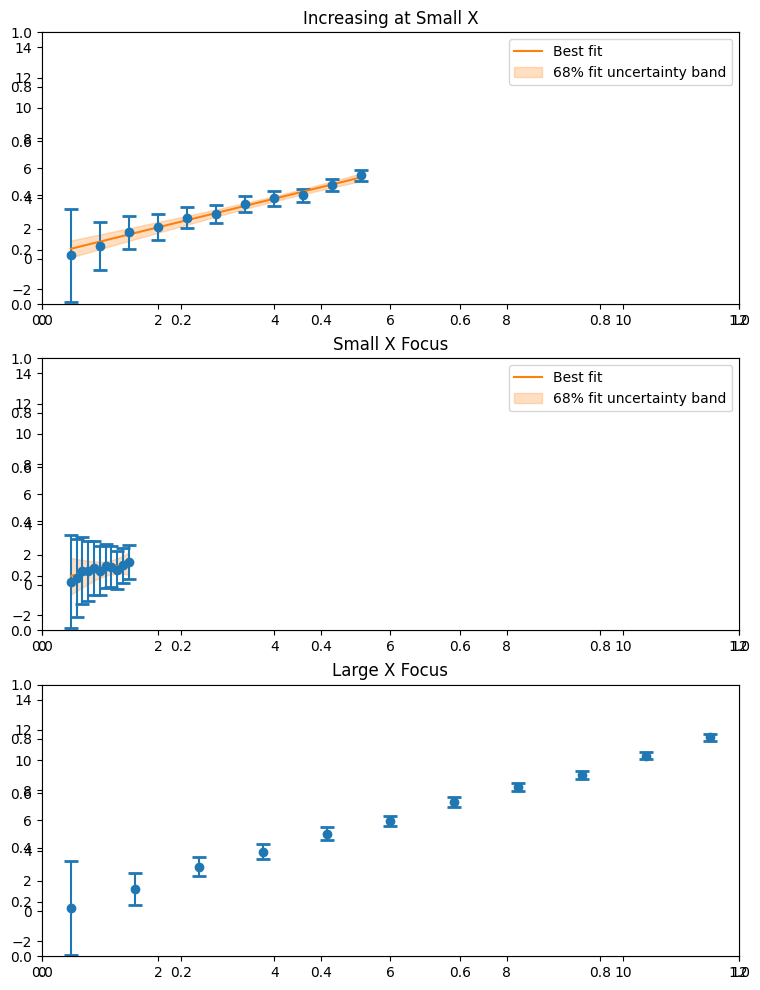

In [18]:
# create some fake data

npts = 11
xlow = 0.5
xhigh = 11.5

xl = xlow + 0.01
xmid = (xhigh+xlow)/2.0+0.01

xi = np.linspace(xlow,xhigh,npts)
yi = xi + yrandom

sigmai = np.array([0.1+ 1.5/np.abs(xi[i]) for i in range(npts)])
plot3.errorbar(xi, yi, yerr=sigmai, fmt='o', capsize=5, capthick=2)
plot3.set_title("Large X Focus")
plot3.set_xlim([0,12])
plot3.set_ylim([-3,15])

figure2

Chi^2 / dof = 1.759 / 9
Reduced chi^2 = 0.195
Coefficients (from curve_fit)
[0.19418997 0.973786  ]
Covariance Matrix (from curve_fit)
[[ 0.12895701 -0.01393478]
 [-0.01393478  0.00164001]]

Final Result: y = (0.97 +/- 0.04) x + (0.19 +/- 0.36)


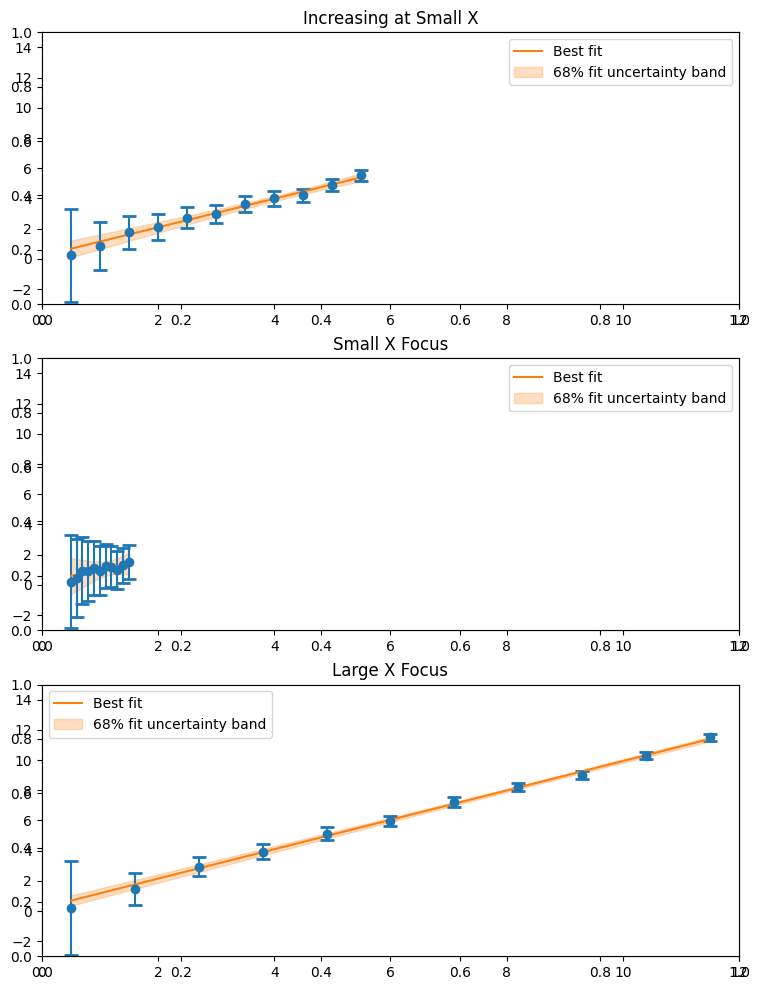

In [19]:
init_vals = [0.0 for x in range(2)]
popt, pcov = curve_fit(fitfunction,xi,yi,p0=init_vals,sigma=sigmai,
                       absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

ps = rng.multivariate_normal(popt,pcov,10000)
ysample=np.asarray([fitfunction(xi,*pi) for pi in ps])

lower = np.percentile(ysample,16.0,axis=0)
upper = np.percentile(ysample,84.0,axis=0)
report_fit_diagnostics(xi, yi, popt, sigmai)

print("Coefficients (from curve_fit)")
print (popt)
print("Covariance Matrix (from curve_fit)")
print (pcov)

print()
print ("Final Result: y = (%0.2f +/- %0.2f) x + (%0.2f +/- %0.2f)" % (popt[1],perr[1],popt[0],perr[0]))

fit_line, = plot3.plot(xi, fitfunction(xi, *popt), label='Best fit')
plot3.fill_between(xi, lower, upper, color=fit_line.get_color(), alpha=0.25,
                   label='68% fit uncertainty band')
plot3.legend()

slope.append(popt[1])
dslope.append(perr[1])
yint.append(popt[0])
dyint.append(perr[0])
type.append('Large X Range')

figure2

In [20]:
df = pd.DataFrame({'Fit Type':type, 'Slope':slope, 'Error in Slope':dslope, 'Y Intercept':yint, 'Error in Y Intercept':dyint})
df.head(10)

,Fit Type,Slope,Error in Slope,Y Intercept,Error in Y Intercept
0,None,0.994090,0.037188,0.004040,0.126109
1,Uniform,0.994090,0.095347,0.004040,0.323336
2,Increasing,1.139413,0.097276,-0.328050,0.099114
3,Endpoints,0.957397,0.104172,0.134675,0.321576
4,Increasing at Small X,0.948022,0.146517,0.184942,0.633879
5,Small X Range,0.828904,1.689146,0.175923,2.034381
6,Large X Range,0.973786,0.040497,0.194190,0.359106


## Conclusions

1. For this linear model, this particular uncertainty pattern, a fixed number of measurements, and the simulated noise used here, increasing the range of $x$ provides a longer lever arm and improves the determination of both slope and intercept. This is a lesson about the present experimental-design assumptions, not a universal rule: changing the model, available measurement time, uncertainty model, or systematic errors could change the preferred design.
